NYPD Hate Crimes

In [2]:
from google.colab import files
uploaded=files.upload()

import pandas as pd
df=pd.read_csv("NYPD_Hate_Crimes_20260410.csv")
df.head()

Saving NYPD_Hate_Crimes_20260410.csv to NYPD_Hate_Crimes_20260410.csv


,Full Complaint ID,Complaint Year Number,Month Number,Record Create Date,Complaint Precinct Code,Patrol Borough Name,County,Law Code Category Description,Offense Description,PD Code Description,Bias Motive Description,Offense Category,Arrest Date,Arrest Id
0,201906012119317,2019,1,01/23/2019,60,PATROL BORO BKLYN SOUTH,KINGS,FELONY,MISCELLANEOUS PENAL LAW,AGGRAVATED HARASSMENT 1,ANTI-JEWISH,Religion/Religious Practice,NaN,NaN
1,201906012175717,2019,2,02/25/2019,60,PATROL BORO BKLYN SOUTH,KINGS,FELONY,MISCELLANEOUS PENAL LAW,AGGRAVATED HARASSMENT 1,ANTI-JEWISH,Religion/Religious Practice,NaN,NaN
2,201906012180117,2019,2,02/27/2019,60,PATROL BORO BKLYN SOUTH,KINGS,FELONY,MISCELLANEOUS PENAL LAW,AGGRAVATED HARASSMENT 1,ANTI-JEWISH,Religion/Religious Practice,NaN,NaN
3,201906012273417,2019,4,04/16/2019,60,PATROL BORO BKLYN SOUTH,KINGS,FELONY,MISCELLANEOUS PENAL LAW,AGGRAVATED HARASSMENT 1,ANTI-JEWISH,Religion/Religious Practice,NaN,NaN
4,201906012413717,2019,6,06/20/2019,60,PATROL BORO BKLYN SOUTH,KINGS,FELONY,MISCELLANEOUS PENAL LAW,AGGRAVATED HARASSMENT 1,ANTI-JEWISH,Religion/Religious Practice,NaN,NaN


In [3]:
df.columns

Index(['Full Complaint ID', 'Complaint Year Number', 'Month Number',
       'Record Create Date', 'Complaint Precinct Code', 'Patrol Borough Name',
       'County', 'Law Code Category Description', 'Offense Description',
       'PD Code Description', 'Bias Motive Description', 'Offense Category',
       'Arrest Date', 'Arrest Id'],
      dtype='object')

In [4]:
df['County'].value_counts()

,count
County,
NEW YORK,1477
KINGS,1433
QUEENS,749
BRONX,226
RICHMOND,144


In [5]:
df_kings=df[df['County']=='KINGS']
df_kings.head()

,Full Complaint ID,Complaint Year Number,Month Number,Record Create Date,Complaint Precinct Code,Patrol Borough Name,County,Law Code Category Description,Offense Description,PD Code Description,Bias Motive Description,Offense Category,Arrest Date,Arrest Id
0,201906012119317,2019,1,01/23/2019,60,PATROL BORO BKLYN SOUTH,KINGS,FELONY,MISCELLANEOUS PENAL LAW,AGGRAVATED HARASSMENT 1,ANTI-JEWISH,Religion/Religious Practice,NaN,NaN
1,201906012175717,2019,2,02/25/2019,60,PATROL BORO BKLYN SOUTH,KINGS,FELONY,MISCELLANEOUS PENAL LAW,AGGRAVATED HARASSMENT 1,ANTI-JEWISH,Religion/Religious Practice,NaN,NaN
2,201906012180117,2019,2,02/27/2019,60,PATROL BORO BKLYN SOUTH,KINGS,FELONY,MISCELLANEOUS PENAL LAW,AGGRAVATED HARASSMENT 1,ANTI-JEWISH,Religion/Religious Practice,NaN,NaN
3,201906012273417,2019,4,04/16/2019,60,PATROL BORO BKLYN SOUTH,KINGS,FELONY,MISCELLANEOUS PENAL LAW,AGGRAVATED HARASSMENT 1,ANTI-JEWISH,Religion/Religious Practice,NaN,NaN
4,201906012413717,2019,6,06/20/2019,60,PATROL BORO BKLYN SOUTH,KINGS,FELONY,MISCELLANEOUS PENAL LAW,AGGRAVATED HARASSMENT 1,ANTI-JEWISH,Religion/Religious Practice,NaN,NaN


In [6]:
df_kings['Bias Motive Description'].value_counts()

,count
Bias Motive Description,
ANTI-JEWISH,798
ANTI-MALE HOMOSEXUAL (GAY),120
ANTI-BLACK,99
ANTI-OTHER ETHNICITY,96
ANTI-ASIAN,80
ANTI-MUSLIM,59
ANTI-WHITE,36
ANTI-FEMALE,31
ANTI-TRANSGENDER,26


In [9]:
df_kings = df[df['County'] == 'KINGS']
df_queens = df[df['County'] == 'QUEENS']

kings_counts = df_kings['Bias Motive Description'].value_counts()
queens_counts = df_queens['Bias Motive Description'].value_counts()

print(kings_counts)
print(queens_counts)

Bias Motive Description
ANTI-JEWISH                          798
ANTI-MALE HOMOSEXUAL (GAY)           120
ANTI-BLACK                            99
ANTI-OTHER ETHNICITY                  96
ANTI-ASIAN                            80
ANTI-MUSLIM                           59
ANTI-WHITE                            36
ANTI-FEMALE                           31
ANTI-TRANSGENDER                      26
ANTI-CATHOLIC                         25
ANTI-FEMALE HOMOSEXUAL (LESBIAN)      20
ANTI-HISPANIC                         19
ANTI-GENDER NON-CONFORMING             4
ANTI-LGBT (MIXED GROUP)                4
ANTI-ARAB                              4
ANTI-PROTESTANT                        3
ANTI-BUDDHIST                          3
ANTI-RELIGIOUS PRACTICE GENERALLY      1
ANTI-SIKH                              1
ANTI-OTHER RELIGION                    1
ANTI-EASTERN ORTHODOX                  1
ANTI-MALE                              1
ANTI-MORMON                            1
Name: count, dtype: int64
Bias Mo

KINGS county (Brooklyn) has a higher count of anti-Jewish bias incidents than QUEENS county suggesting that this type of bias is more prevalent in Brooklyn within the dataset.

In [10]:

kings_aj = df_kings[df_kings['Bias Motive Description'] == 'ANTI-JEWISH'].shape[0]
queens_aj = df_queens[df_queens['Bias Motive Description'] == 'ANTI-JEWISH'].shape[0]

print(kings_aj, queens_aj)

798 289


In [18]:
df['County'] = df['County'].str.strip().str.upper()
print(df['Bias Motive Description'].head())

0    ANTI-JEWISH
1    ANTI-JEWISH
2    ANTI-JEWISH
3    ANTI-JEWISH
4    ANTI-JEWISH
Name: Bias Motive Description, dtype: object


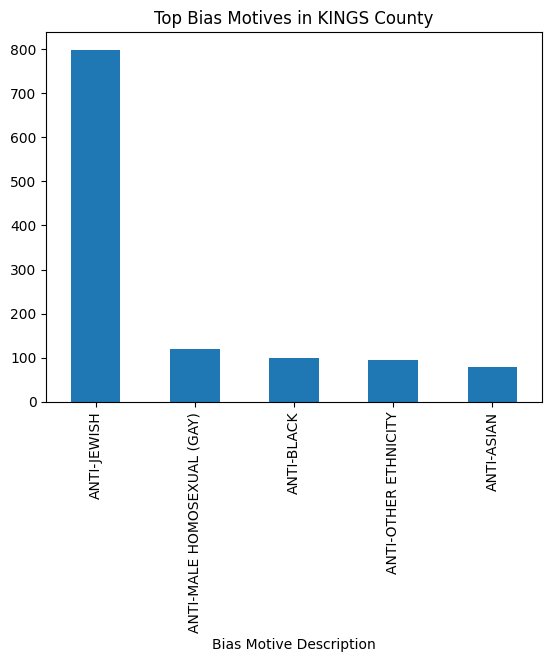

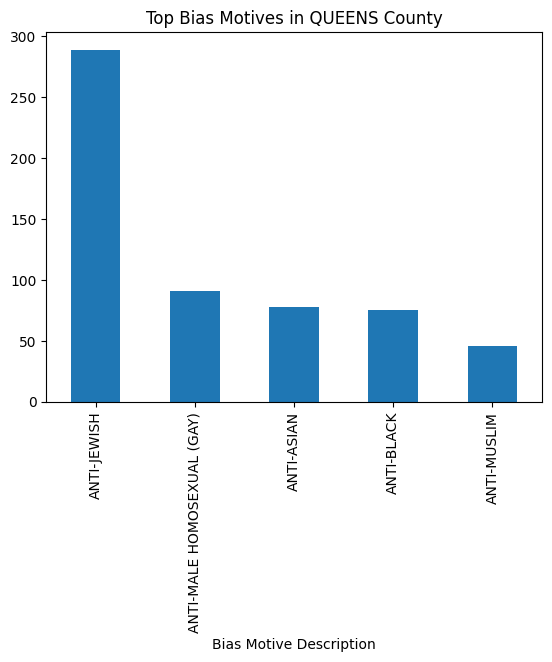

In [19]:
import matplotlib.pyplot as plt


kings_counts = df_kings['Bias Motive Description'].value_counts().head(5)
queens_counts = df_queens['Bias Motive Description'].value_counts().head(5)


kings_counts.plot(kind='bar', title='Top Bias Motives in KINGS County')
plt.show()

queens_counts.plot(kind='bar', title='Top Bias Motives in QUEENS County')
plt.show()

The analysis shows that KINGS county has a higher number of anti-Jewish bias incidents compared to QUEENS county. While this suggests a difference in the distribution of bias motives, the results may be influenced by reporting patterns, population differences, or data collection methods. This introduces potential bias in the dataset, meaning the findings may not fully represent actual incident rates.